U=0, J=0.8, mu=-2.5, n=0.202269, doping=0.797731, Delta0=0, diamagnetic=0.966117, paramagnetic=1.00633, Ds=-0.0402156
U=0, J=0.8, mu=-2.475, n=0.208262, doping=0.791738, Delta0=0, diamagnetic=0.987141, paramagnetic=1.04749, Ds=-0.0603446
U=0, J=0.8, mu=-2.45, n=0.213571, doping=0.786429, Delta0=0, diamagnetic=1.00566, paramagnetic=0.853321, Ds=0.152336
U=0, J=0.8, mu=-2.425, n=0.218796, doping=0.781204, Delta0=0, diamagnetic=1.02341, paramagnetic=1.17103, Ds=-0.147621
U=0, J=0.8, mu=-2.4, n=0.224998, doping=0.775002, Delta0=0, diamagnetic=1.04429, paramagnetic=1.02894, Ds=0.0153574
U=0, J=0.8, mu=-2.375, n=0.230135, doping=0.769865, Delta0=0, diamagnetic=1.06144, paramagnetic=0.905255, Ds=0.156188
U=0, J=0.8, mu=-2.35, n=0.235897, doping=0.764103, Delta0=0, diamagnetic=1.08015, paramagnetic=1.29133, Ds=-0.211184
U=0, J=0.8, mu=-2.325, n=0.242142, doping=0.757858, Delta0=0, diamagnetic=1.10032, paramagnetic=1.01249, Ds=0.0878329
U=0, J=0.8, mu=-2.3, n=0.247203, doping=0.752797, Delta0=0

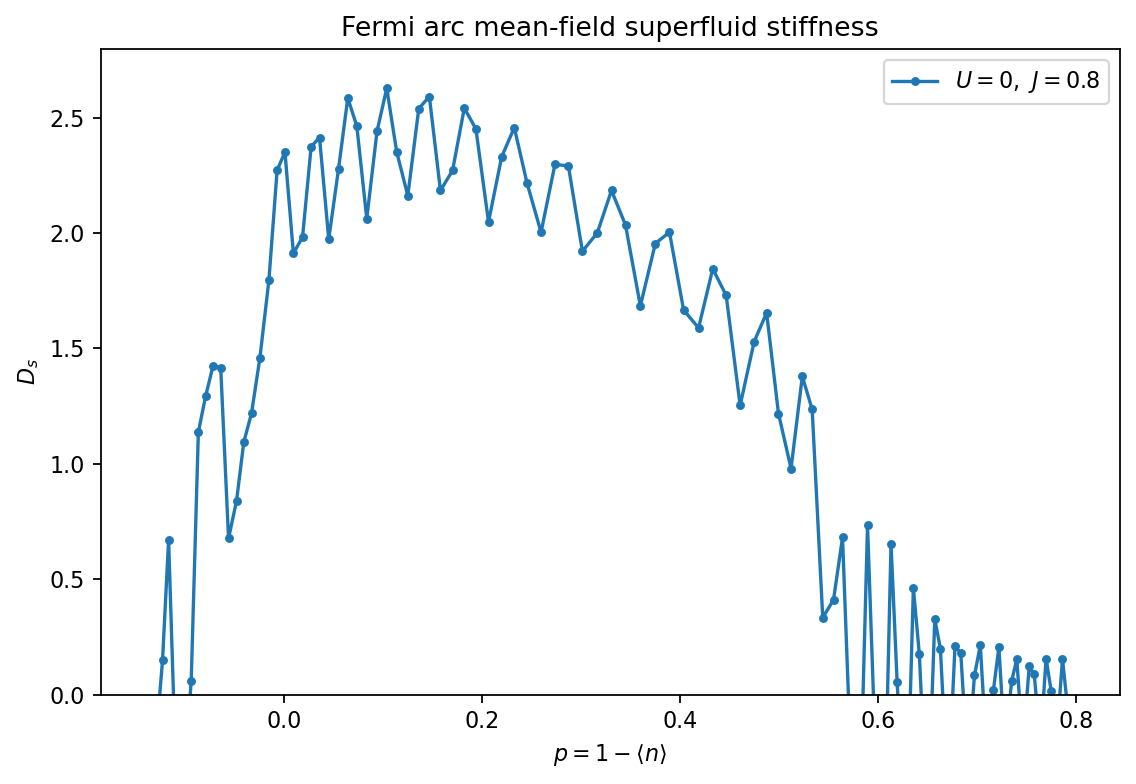

In [ ]:
#Fermi arc
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def velocity_x(kx, ky, hop):
    """d epsilon_k / d kx."""
    t1, t2 = hop
    return (
        2.0 * np.sin(kx)
        + 4.0 * t1 * np.sin(kx) * np.cos(ky)
        + 8.0 * t2 * np.sin(kx) * np.cos(kx)
    )


def curvature_xx(kx, ky, hop):
    """d^2 epsilon_k / d kx^2."""
    t1, t2 = hop
    return (
        2.0 * np.cos(kx)
        + 4.0 * t1 * np.cos(kx) * np.cos(ky)
        + 8.0 * t2 * (np.cos(kx) ** 2 - np.sin(kx) ** 2)
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)
    # return 1


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


# def quarter_bz_kmesh(nk1d):
#     """Quarter-BZ mesh 0 <= kx < pi, 0 <= ky < pi for stiffness integrals."""
#     points = []
#     weights = []
#     for ix in range(nk1d):
#         for iy in range(nk1d):
#             kx = ix * np.pi / nk1d
#             ky = iy * np.pi / nk1d
#             points.append((kx, ky))
#             weights.append(1.0)
#     return np.array(points, dtype=float), np.array(weights, dtype=float)

def quarter_bz_midpoint_kmesh(nk1d):
    points = []
    weights = []
    grid = (np.arange(nk1d) + 0.5) * np.pi / nk1d

    for kx in grid:
        for ky in grid:
            points.append((kx, ky))
            weights.append(1.0)

    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def stiffness_observables_for_k(
    kx,
    ky,
    mu,
    hop,
    U,
    Delta0,
    beta,
    compute_stiffness=True,
):
    """
    Return filling contribution and Kubo stiffness integrands for one sector.

    If compute_stiffness is False, only the filling is computed. This avoids
    evaluating the current-current response when the caller will set the
    superconducting stiffness to zero for a tiny gap.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    filling = 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real

    if not compute_stiffness:
        return filling, 0.0, 0.0, 0.0

    momenta = [
        (kx, ky),
        (kx + np.pi, ky + np.pi),
        (-kx, -ky),
        (-kx - np.pi, -ky - np.pi),
    ]
    velocities = [velocity_x(px, py, hop) for px, py in momenta]
    curvatures = [curvature_xx(px, py, hop) for px, py in momenta]

    jx_op = sum(v * n for v, n in zip(velocities, N_OPS))
    kxx_op = sum(kxx * n for kxx, n in zip(curvatures, N_OPS))

    kxx_eigenbasis = vectors.conj().T @ kxx_op @ vectors
    jx_eigenbasis = vectors.conj().T @ jx_op @ vectors

    kxx_expect = np.sum(rho * np.diag(kxx_eigenbasis)).real

    paramagnetic = 0.0
    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            matrix_element = abs(jx_eigenbasis[n, m]) ** 2
            denom = e_n - e_m
            if abs(denom) < 1e-12:
                factor = beta * rho[m]
                # factor = beta * rho[m] * (1.0 - rho[m])
            else:
                factor = (rho[m] - rho[n]) / denom
            paramagnetic += matrix_element * factor

    diamagnetic = float(np.real(kxx_expect))
    paramagnetic = float(np.real(paramagnetic))
    return filling, diamagnetic - paramagnetic, diamagnetic, paramagnetic


def superfluid_stiffness(
    k_gap_points,
    k_gap_weights,
    k_stiffness_points,
    k_stiffness_weights,
    J,
    mu,
    hop,
    U,
    beta,
    # gap_tol=5e-3,
    gap_tol=0.0,
    clip_negative=True,
):
    """
    Compute filling, D_s, and self-consistent Delta0.

    Delta0 is solved on the triangular mesh. Filling and stiffness terms are
    evaluated on a separate stiffness mesh, intended to be the full 1/4 BZ.
    """
    Delta0 = solve_gap_delta0(
        k_gap_points,
        k_gap_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )

    compute_stiffness = abs(Delta0) >= gap_tol
    fillings = []
    stiffness_parts = []
    diamagnetic_parts = []
    paramagnetic_parts = []
    for (kx, ky), weight in zip(k_stiffness_points, k_stiffness_weights):
        filling_k, stiffness_k, diamagnetic_k, paramagnetic_k = stiffness_observables_for_k(
            kx,
            ky,
            mu,
            hop,
            U,
            Delta0,
            beta,
            compute_stiffness=compute_stiffness,
        )
        fillings.append(weight * filling_k)
        if compute_stiffness:
            stiffness_parts.append(weight * stiffness_k)
            diamagnetic_parts.append(weight * diamagnetic_k)
            paramagnetic_parts.append(weight * paramagnetic_k)
    filling = np.sum(fillings) / np.sum(k_stiffness_weights)

    if not compute_stiffness:
        return filling, 0.0, Delta0, 0.0, 0.0

    ds_over_pi = np.sum(stiffness_parts) / np.sum(k_stiffness_weights)
    stiffness = np.pi * 0.5 * ds_over_pi
    diamagnetic = np.pi * 0.5 * np.sum(diamagnetic_parts) / np.sum(k_stiffness_weights)
    paramagnetic = np.pi * 0.5 * np.sum(paramagnetic_parts) / np.sum(k_stiffness_weights)

    return filling, stiffness, Delta0, diamagnetic, paramagnetic


# -------------------------- user parameters --------------------------
# hop = np.array([0, 0])
hop = np.array([-0.2, 0.1])
U_values = [0]
J_values = [0.8]
# temperature = 1e-04 * J_values[0]
# beta = 1.0 / temperature
beta = 100

# Increase nk_gap and the number of mu_values for smoother final figures.
nk_gap_delta = 32
nk_gap_stiffness = 64

mu_values = np.linspace(-2.5, 0, 101)
# mu_values = np.linspace(-4.8, 4.8, 11)
# mu_values = [-2.29167]

k_gap_points, k_gap_weights = triangular_kmesh(nk_gap_delta)
# k_gap_points, k_gap_weights = quarter_bz_midpoint_kmesh(nk_gap_delta)
k_stiffness_points, k_stiffness_weights = quarter_bz_midpoint_kmesh(nk_gap_stiffness)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for U in U_values:
    for J in J_values:
        fillings = []
        dopings = []
        stiffnesses = []
        gaps = []
        curve_start = time.time()

        for mu in mu_values:
            filling, stiffness, Delta0, diamagnetic, paramagnetic = superfluid_stiffness(
                k_gap_points,
                k_gap_weights,
                k_stiffness_points,
                k_stiffness_weights,
                J=J,
                mu=mu,
                hop=hop,
                U=U,
                beta=beta,
            )
            fillings.append(filling)
            dopings.append(1.0 - filling)
            stiffnesses.append(stiffness)
            gaps.append(Delta0)
            print(
                f"U={U:.6g}, J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, "
                f"doping={1.0 - filling:.6g}, "
                f"Delta0={Delta0:.6g}, diamagnetic={diamagnetic:.6g}, "
                f"paramagnetic={paramagnetic:.6g}, Ds={stiffness:.6g}"
            )

        order = np.argsort(dopings)
        plt.plot(
            np.array(dopings)[order],
            np.array(stiffnesses)[order],
            marker="o",
            markersize=3,
            label=rf"$U={U:.3g},\ J={J:.3g}$",
        )
        print(
            f"Finished U={U:.6g}, J={J:.6g}; "
            f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
            f"in {time.time() - curve_start:.2f} s"
        )
        np.save(
            f"stiffness_nkdelta{nk_gap_delta}_nkstiff{nk_gap_stiffness}_U={U}_J={J}_beta={beta}",
            np.array(stiffnesses),
        )
        np.save(
            f"doping_nkdelta{nk_gap_delta}_nkstiff{nk_gap_stiffness}_U={U}_J={J}_beta={beta}",
            np.array(dopings),
        )

plt.xlabel(r"$p=1-\langle n\rangle$")
plt.ylabel(r"$D_s$")
plt.title(r"Fermi arc mean-field superfluid stiffness")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_superfluid_stiffness_complete.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")


U=0, J=0.8, mu=-2.5, n=0.202269, doping=0.797731, Delta0=0, diamagnetic=0.966117, paramagnetic=1.00633, Ds=-0.0402156
U=0, J=0.8, mu=-2.475, n=0.208262, doping=0.791738, Delta0=0, diamagnetic=0.987141, paramagnetic=1.04749, Ds=-0.0603446
U=0, J=0.8, mu=-2.45, n=0.213571, doping=0.786429, Delta0=0, diamagnetic=1.00566, paramagnetic=0.853321, Ds=0.152336
U=0, J=0.8, mu=-2.425, n=0.218796, doping=0.781204, Delta0=0, diamagnetic=1.02341, paramagnetic=1.17103, Ds=-0.147621
U=0, J=0.8, mu=-2.4, n=0.224998, doping=0.775002, Delta0=0, diamagnetic=1.04429, paramagnetic=1.02894, Ds=0.0153574
U=0, J=0.8, mu=-2.375, n=0.230135, doping=0.769865, Delta0=0, diamagnetic=1.06144, paramagnetic=0.905255, Ds=0.156188
U=0, J=0.8, mu=-2.35, n=0.235897, doping=0.764103, Delta0=0, diamagnetic=1.08015, paramagnetic=1.29133, Ds=-0.211184
U=0, J=0.8, mu=-2.325, n=0.242142, doping=0.757858, Delta0=0, diamagnetic=1.10032, paramagnetic=1.01249, Ds=0.0878329
U=0, J=0.8, mu=-2.3, n=0.247203, doping=0.752797, Delta0=0

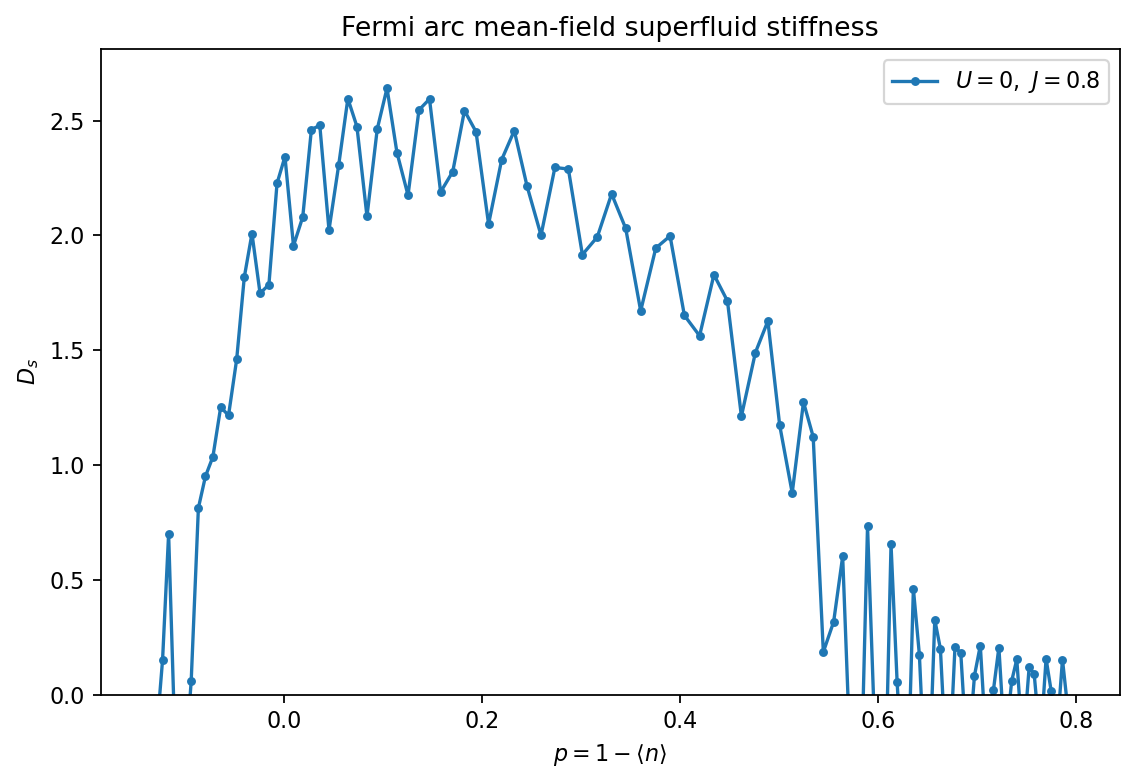

In [2]:
#Fermi arc
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def velocity_x(kx, ky, hop):
    """d epsilon_k / d kx."""
    t1, t2 = hop
    return (
        2.0 * np.sin(kx)
        + 4.0 * t1 * np.sin(kx) * np.cos(ky)
        + 8.0 * t2 * np.sin(kx) * np.cos(kx)
    )


def curvature_xx(kx, ky, hop):
    """d^2 epsilon_k / d kx^2."""
    t1, t2 = hop
    return (
        2.0 * np.cos(kx)
        + 4.0 * t1 * np.cos(kx) * np.cos(ky)
        + 8.0 * t2 * (np.cos(kx) ** 2 - np.sin(kx) ** 2)
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)
    # return 1


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


# def quarter_bz_kmesh(nk1d):
#     """Quarter-BZ mesh 0 <= kx < pi, 0 <= ky < pi for stiffness integrals."""
#     points = []
#     weights = []
#     for ix in range(nk1d):
#         for iy in range(nk1d):
#             kx = ix * np.pi / nk1d
#             ky = iy * np.pi / nk1d
#             points.append((kx, ky))
#             weights.append(1.0)
#     return np.array(points, dtype=float), np.array(weights, dtype=float)

def quarter_bz_midpoint_kmesh(nk1d):
    points = []
    weights = []
    grid = (np.arange(nk1d) + 0.5) * np.pi / nk1d

    for kx in grid:
        for ky in grid:
            points.append((kx, ky))
            weights.append(1.0)

    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def stiffness_observables_for_k(
    kx,
    ky,
    mu,
    hop,
    U,
    Delta0,
    beta,
    compute_stiffness=True,
):
    """
    Return filling contribution and Kubo stiffness integrands for one sector.

    If compute_stiffness is False, only the filling is computed. This avoids
    evaluating the current-current response when the caller will set the
    superconducting stiffness to zero for a tiny gap.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    filling = 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real

    if not compute_stiffness:
        return filling, 0.0, 0.0, 0.0

    momenta = [
        (kx, ky),
        (kx + np.pi, ky + np.pi),
        (-kx, -ky),
        (-kx - np.pi, -ky - np.pi),
    ]
    velocities = [velocity_x(px, py, hop) for px, py in momenta]
    curvatures = [curvature_xx(px, py, hop) for px, py in momenta]

    jx_op = sum(v * n for v, n in zip(velocities, N_OPS))
    kxx_op = sum(kxx * n for kxx, n in zip(curvatures, N_OPS))

    kxx_eigenbasis = vectors.conj().T @ kxx_op @ vectors
    jx_eigenbasis = vectors.conj().T @ jx_op @ vectors

    kxx_expect = np.sum(rho * np.diag(kxx_eigenbasis)).real

    paramagnetic = 0.0
    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            matrix_element = abs(jx_eigenbasis[n, m]) ** 2
            denom = e_n - e_m
            if abs(denom) < 1e-12:
                factor = beta * rho[m]
                # factor = beta * rho[m] * (1.0 - rho[m])
            else:
                factor = (rho[m] - rho[n]) / denom
            paramagnetic += matrix_element * factor

    diamagnetic = float(np.real(kxx_expect))
    paramagnetic = float(np.real(paramagnetic))
    return filling, diamagnetic - paramagnetic, diamagnetic, paramagnetic


def superfluid_stiffness(
    k_gap_points,
    k_gap_weights,
    k_stiffness_points,
    k_stiffness_weights,
    J,
    mu,
    hop,
    U,
    beta,
    # gap_tol=5e-3,
    gap_tol=0.0,
    clip_negative=True,
):
    """
    Compute filling, D_s, and self-consistent Delta0.

    Delta0 is solved on the triangular mesh. Filling and stiffness terms are
    evaluated on a separate stiffness mesh, intended to be the full 1/4 BZ.
    """
    Delta0 = solve_gap_delta0(
        k_gap_points,
        k_gap_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )

    compute_stiffness = abs(Delta0) >= gap_tol
    fillings = []
    stiffness_parts = []
    diamagnetic_parts = []
    paramagnetic_parts = []
    for (kx, ky), weight in zip(k_stiffness_points, k_stiffness_weights):
        filling_k, stiffness_k, diamagnetic_k, paramagnetic_k = stiffness_observables_for_k(
            kx,
            ky,
            mu,
            hop,
            U,
            Delta0,
            beta,
            compute_stiffness=compute_stiffness,
        )
        fillings.append(weight * filling_k)
        if compute_stiffness:
            stiffness_parts.append(weight * stiffness_k)
            diamagnetic_parts.append(weight * diamagnetic_k)
            paramagnetic_parts.append(weight * paramagnetic_k)
    filling = np.sum(fillings) / np.sum(k_stiffness_weights)

    if not compute_stiffness:
        return filling, 0.0, Delta0, 0.0, 0.0

    ds_over_pi = np.sum(stiffness_parts) / np.sum(k_stiffness_weights)
    stiffness = np.pi * 0.5 * ds_over_pi
    diamagnetic = np.pi * 0.5 * np.sum(diamagnetic_parts) / np.sum(k_stiffness_weights)
    paramagnetic = np.pi * 0.5 * np.sum(paramagnetic_parts) / np.sum(k_stiffness_weights)

    return filling, stiffness, Delta0, diamagnetic, paramagnetic


# -------------------------- user parameters --------------------------
# hop = np.array([0, 0])
hop = np.array([-0.2, 0.1])
U_values = [0]
J_values = [0.8]
# temperature = 1e-04 * J_values[0]
# beta = 1.0 / temperature
beta = 100

# Increase nk_gap and the number of mu_values for smoother final figures.
nk_gap_delta = 64
nk_gap_stiffness = 64

mu_values = np.linspace(-2.5, 0, 101)
# mu_values = np.linspace(-4.8, 4.8, 11)
# mu_values = [-2.29167]

k_gap_points, k_gap_weights = triangular_kmesh(nk_gap_delta)
# k_gap_points, k_gap_weights = quarter_bz_midpoint_kmesh(nk_gap_delta)
k_stiffness_points, k_stiffness_weights = quarter_bz_midpoint_kmesh(nk_gap_stiffness)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for U in U_values:
    for J in J_values:
        fillings = []
        dopings = []
        stiffnesses = []
        gaps = []
        curve_start = time.time()

        for mu in mu_values:
            filling, stiffness, Delta0, diamagnetic, paramagnetic = superfluid_stiffness(
                k_gap_points,
                k_gap_weights,
                k_stiffness_points,
                k_stiffness_weights,
                J=J,
                mu=mu,
                hop=hop,
                U=U,
                beta=beta,
            )
            fillings.append(filling)
            dopings.append(1.0 - filling)
            stiffnesses.append(stiffness)
            gaps.append(Delta0)
            print(
                f"U={U:.6g}, J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, "
                f"doping={1.0 - filling:.6g}, "
                f"Delta0={Delta0:.6g}, diamagnetic={diamagnetic:.6g}, "
                f"paramagnetic={paramagnetic:.6g}, Ds={stiffness:.6g}"
            )

        order = np.argsort(dopings)
        plt.plot(
            np.array(dopings)[order],
            np.array(stiffnesses)[order],
            marker="o",
            markersize=3,
            label=rf"$U={U:.3g},\ J={J:.3g}$",
        )
        print(
            f"Finished U={U:.6g}, J={J:.6g}; "
            f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
            f"in {time.time() - curve_start:.2f} s"
        )
        np.save(
            f"stiffness_nkdelta{nk_gap_delta}_nkstiff{nk_gap_stiffness}_U={U}_J={J}_beta={beta}",
            np.array(stiffnesses),
        )
        np.save(
            f"doping_nkdelta{nk_gap_delta}_nkstiff{nk_gap_stiffness}_U={U}_J={J}_beta={beta}",
            np.array(dopings),
        )

plt.xlabel(r"$p=1-\langle n\rangle$")
plt.ylabel(r"$D_s$")
plt.title(r"Fermi arc mean-field superfluid stiffness")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_superfluid_stiffness_complete.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")
